In [1]:
list.of.packages <- c("tidyverse","fixest","stargazer","ggfixest","ggplot2","patchwork","ggpubr","data.table")
new.packages <- list.of.packages[!(list.of.packages %in% installed.packages()[,"Package"])]
if(length(new.packages)) install.packages(new.packages, repos = "http://cran.us.r-project.org")

invisible(lapply(list.of.packages, library, character.only = TRUE))

options(repr.matrix.max.rows=500, repr.matrix.max.cols=500)  

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 



Attachement du package : ‘data.table’


Les objets suivants sont masqués depuis ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


Les objet

In [2]:
T_bins_labels <- c("<=17°C","17,21]","21,23]","23,25]","25,27]","27,29]","29,31]","31,33]",">33°C")
T_bins_labels_pretty <- c("≤17°C", "(17,21]", "(21,23]", "(23,25]", "(25,27]", "(27,29]", "(29,31]", "(31,33]", ">33°C")
T_bins_labels_pretty_wo_ref <- c("≤17°C", "(21,23]", "(23,25]", "(25,27]", "(27,29]", "(29,31]", "(31,33]", ">33°C")

bin_ref_T <-"17,21]"

In [3]:
varT <- "T_i30_bin"
varT_permut <- "T_i30_bin_permut"

dict_levels_T <- setNames(paste0("T: ",T_bins_labels_pretty), paste0(varT, "::", T_bins_labels))
dict_levels_T_perm <- setNames(paste0("T permut: ",T_bins_labels_pretty), paste0(varT_permut, "::", T_bins_labels))

dict <- c(dict_levels_T, dict_levels_T_perm)

# Children

In [4]:
df_children <- fread("./2_Regression_datasets/output/df_reg_children.csv")
sprintf("%i rows x %i columns", nrow(df_children), ncol(df_children))
head(df_children,2)

[1] "281812 rows x 321 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Mother_id,Child_id,Resp_nb,Interview_month,Interview_year,Measured_date_CDC,Measured_date,Measured_day,Measured_month,Measured_year,Birth_month,Birth_year,Child_female,Child_birth_order,Child_alive_age_month,Child_hemo_level_alti,Child_weight_for_height_zscore,Child_diarrhea,Child_fever,Child_cough,Child_still_breastfeeding,Child_given_plain_water,Child_given_juice,Child_given_milk,Child_given_baby_formula,Child_given_fortified_baby_food,Child_given_soup,Child_given_other_liquid,Child_given_chicken_duck_birds,Child_given_bread_noodles_grains,Child_given_potatoes_cassava_tubers,Child_given_eggs,Child_given_pumkins_carrots_squash,Child_given_green_vegetables,Child_given_mangoes_papaya_vitaminAfruits,Child_given_other_fruits,Child_given_liver_heart_organs,Child_given_fish_sellfish,Child_given_beans_peas_lentils_nuts,Child_given_cheese_yogurt_milk_products,Child_given_other_solid_semisolid_food,Child_given_other_meat,Child_given_yogurt,Child_iron_supplem_7d,Mother_no_educ,Mother_prim_educ,Mother_second_educ,Mother_higher_educ,Mother_hindu,Mother_muslim,Mother_not_hindu_nor_muslim,Mother_ethni_SC,Mother_ethni_ST,Mother_ethni_OBC,Mother_ethni_other,Mother_height,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,Interview_cdc,Wasted,Age_rounded,Children_anemia,Child_severe_anemia,Child_moderate_anemia,Child_mild_anemia,Child_no_anemia,Season,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_

In [5]:
df_reg_children <- df_children %>%
                mutate(T_i30_bin=factor(gsub("\\(","",T_i30_bin),levels=T_bins_labels)
)

# Actual model

In [6]:
reg_children <- feols(Child_hemo_level_alti ~ i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                        Child_female + Child_birth_order + Child_alive_age_month +
                                        Mother_prim_educ + Mother_second_educ + Mother_higher_educ +
                                        Mother_muslim + Mother_not_hindu_nor_muslim  + 
                                        Mother_ethni_SC + Mother_ethni_ST + Mother_ethni_OBC +
                                        Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                        Urban 
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
                           df_reg_children)

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).



In [7]:
actual_coefs <- coef(reg_children)[1:8]

In [8]:
actual_se <- se(reg_children)[1:8]

In [9]:
actual_coefs[1]

T_i30_bin::<=17°C 
       -0.8468942

In [10]:
length(actual_coefs)

[1] 8

In [11]:
names(actual_coefs)

[1] "T_i30_bin::<=17°C" "T_i30_bin::21,23]" "T_i30_bin::23,25]"
[4] "T_i30_bin::25,27]" "T_i30_bin::27,29]" "T_i30_bin::29,31]"
[7] "T_i30_bin::31,33]" "T_i30_bin::>33°C"

# Randomized temperature exposure

In [12]:
# Ensure reproducibility
set.seed(123)

In [13]:
thresholds_T <- c(-17,17,21,23,25,27,29,31,33,40)

In [14]:
df_reg_children_rand <- df_children %>%
                select(Child_hemo_level_alti,T_i30,P_tot_30,
                       Child_female,Child_birth_order, Child_alive_age_month,
                       Mother_prim_educ,Mother_second_educ,Mother_higher_educ,
                       Mother_muslim,Mother_not_hindu_nor_muslim, 
                       Mother_ethni_SC,Mother_ethni_ST,Mother_ethni_OBC,
                       Wealth_lowest,Wealth_second,Wealth_fourth,Wealth_highest,
                       Urban,
                       District_ID,Measured_month,Measured_year)%>%
                mutate(T_i30_permut = sample(T_i30),
                       T_i30_bin_permut = cut(T_i30_permut, breaks = thresholds_T, 
                                           labels = T_bins_labels,
                                           include.lowest = TRUE),
                       T_i30_bin_permut=factor(T_i30_bin_permut,levels = T_bins_labels))
sprintf("%i rows x %i columns", nrow(df_reg_children_rand), ncol(df_reg_children_rand))
head(df_reg_children_rand,2)

[1] "281812 rows x 24 columns"

Child_hemo_level_alti,T_i30,P_tot_30,Child_female,Child_birth_order,Child_alive_age_month,Mother_prim_educ,Mother_second_educ,Mother_higher_educ,Mother_muslim,Mother_not_hindu_nor_muslim,Mother_ethni_SC,Mother_ethni_ST,Mother_ethni_OBC,Wealth_lowest,Wealth_second,Wealth_fourth,Wealth_highest,Urban,District_ID,Measured_month,Measured_year,T_i30_permut,T_i30_bin_permut
<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<int>,<int>,<dbl>,<fct>
112,26.97639,0.2802348,1,1,49,0,1,0,0,0,0,0,0,0,0,1,0,1,Andaman & Nicobar Island_South Andaman,7,2015,26.31667,"25,27]"
118,26.97639,0.2802348,1,1,29,0,0,1,0,0,NA,NA,NA,0,0,1,0,1,Andaman & Nicobar Island_South Andaman,7,2015,24.85833,"23,25]"


# Regression with randomized temperature

In [15]:
reg_children_rand <- feols(Child_hemo_level_alti ~ i(T_i30_bin_permut,ref=bin_ref_T)  + P_tot_30 + 
                                        Child_female + Child_birth_order + Child_alive_age_month +
                                        Mother_prim_educ + Mother_second_educ + Mother_higher_educ +
                                        Mother_muslim + Mother_not_hindu_nor_muslim  + 
                                        Mother_ethni_SC + Mother_ethni_ST + Mother_ethni_OBC +
                                        Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                        Urban 
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
                           df_reg_children_rand)

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).



# Compare actual and randomized models

In [16]:
etable(reg_children,reg_children_rand,
       tex=TRUE,
       fitstat = ~ n + r2 + my,
       drop="%!_bin",
       dict=dict)

\begingroup
\centering
\begin{tabular}{lcc}
   \tabularnewline \midrule \midrule
   Dependent Variable: & \multicolumn{2}{c}{Child\_hemo\_level\_alti}\\
   Model:                         & (1)            & (2)\\  
   \midrule
   \emph{Variables}\\
   T: ≤17°C                       & -0.8469$^{**}$ &   \\   
                                  & (0.3327)       &   \\   
   T: (21,23]                     & 0.2425         &   \\   
                                  & (0.2874)       &   \\   
   T: (23,25]                     & -0.1893        &   \\   
                                  & (0.3819)       &   \\   
   T: (25,27]                     & -0.8522$^{*}$  &   \\   
                                  & (0.4434)       &   \\   
   T: (27,29]                     & -1.848$^{***}$ &   \\   
                                  & (0.5469)       &   \\   
   T: (29,31]                     & -2.729$^{***}$ &   \\   
                                  & (0.6541)       &   \\   
   T: (31,33]       

# Permutations

In [17]:
# Number of permutations
num_permutations <- 100

In [18]:
# Initialize a matrix to store the coefficients from each permutation
coefficients_matrix <- matrix(NA, nrow = num_permutations, ncol = length(actual_coefs))

In [19]:
colnames(coefficients_matrix) <- names(actual_coefs)

In [20]:
for (i in 1:num_permutations) {
            df_permuted <- df_children %>%
                        select(Child_hemo_level_alti,T_i30,P_tot_30,
                               Child_female,Child_birth_order,Child_alive_age_month,
                               Mother_prim_educ,Mother_second_educ,Mother_higher_educ,
                               Mother_muslim,Mother_not_hindu_nor_muslim, 
                               Mother_ethni_SC,Mother_ethni_ST,Mother_ethni_OBC,
                               Wealth_lowest,Wealth_second,Wealth_fourth,Wealth_highest,
                               Urban,
                               District_ID,Measured_month,Measured_year)%>%
                        mutate(T_i30 = sample(T_i30),
                               T_i30_bin = cut(T_i30, breaks = thresholds_T, 
                                                   labels = T_bins_labels,
                                                   include.lowest = TRUE),
                               T_i30_bin=factor(T_i30_bin,levels = T_bins_labels))
            # Fit the model with permuted temperature bins
            reg <- feols(Child_hemo_level_alti ~ i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                        Child_female + Child_birth_order + Child_alive_age_month + 
                                        Mother_prim_educ + Mother_second_educ + Mother_higher_educ +
                                        Mother_muslim + Mother_not_hindu_nor_muslim  + 
                                        Mother_ethni_SC + Mother_ethni_ST + Mother_ethni_OBC +
                                        Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                        Urban 
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
                           df_permuted)
            # Store the coefficients of the permuted temperature bins
            coefficients_matrix[i, ] <- coef(reg)[1:8]
    }

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).

NOTES: 16,652 observ

## Summarize permutation coefficients

In [21]:
coefficients_summary <- apply(coefficients_matrix, 2, function(x) c(mean = mean(x), sd = sd(x)))
coefficients_summary

,T_i30_bin::<=17°C,"T_i30_bin::21,23]","T_i30_bin::23,25]","T_i30_bin::25,27]","T_i30_bin::27,29]","T_i30_bin::29,31]","T_i30_bin::31,33]",T_i30_bin::>33°C
mean,0.002785249,-0.004101321,0.0004660704,0.004166789,0.003261999,0.01957317,0.008436929,0.002216813
sd,0.116942994,0.119830164,0.1090525725,0.102512548,0.099041875,0.11093585,0.135887474,0.138645034


# Plot

In [22]:
# Prepare data for plotting
plot_data <- data.frame(Names = factor(T_bins_labels_pretty_wo_ref,
                                       T_bins_labels_pretty_wo_ref),
                        Actual = actual_coefs,
                        Actual_SD = actual_se,
                        Permuted_Mean = coefficients_summary[1, ],
                        Permuted_SD = coefficients_summary[2, ]
                        )
plot_data

,Names,Actual,Actual_SD,Permuted_Mean,Permuted_SD
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
T_i30_bin::<=17°C,≤17°C,-0.8468942,0.3327489,0.0027852485,0.11694299
"T_i30_bin::21,23]","(21,23]",0.2424847,0.2873886,-0.0041013206,0.11983016
"T_i30_bin::23,25]","(23,25]",-0.1893107,0.3819483,0.0004660704,0.10905257
"T_i30_bin::25,27]","(25,27]",-0.8522119,0.4433727,0.0041667895,0.10251255
"T_i30_bin::27,29]","(27,29]",-1.8478353,0.5468733,0.0032619988,0.09904188
"T_i30_bin::29,31]","(29,31]",-2.7291979,0.6541267,0.0195731670,0.11093585
"T_i30_bin::31,33]","(31,33]",-3.1644935,0.7112387,0.0084369288,0.13588747
T_i30_bin::>33°C,>33°C,-3.1581739,0.8213181,0.0022168126,0.13864503


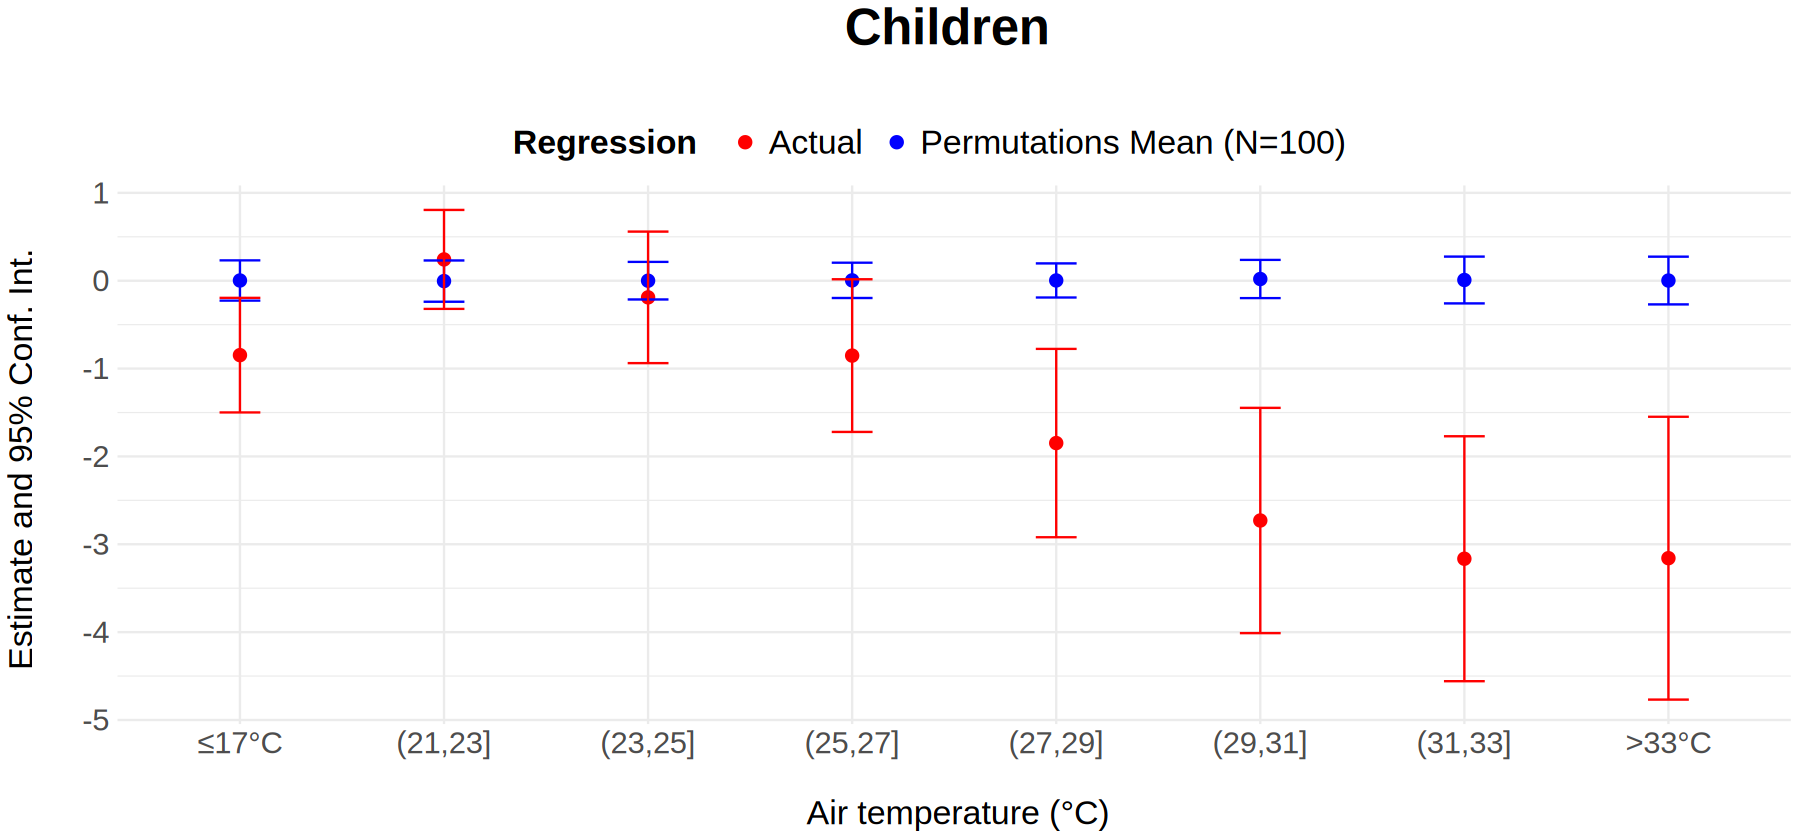

In [23]:
options(repr.plot.width=15, repr.plot.height=7, scipen=9999)

plot <- ggplot(plot_data, aes(x = Names)) +
              geom_point(aes(y = Actual,color="Actual"), size = 3) +
              geom_point(aes(y = Permuted_Mean,color="Permutations Mean (N=100)"), size = 3) +
              geom_errorbar(aes(ymin = Permuted_Mean - 1.96 * Permuted_SD, 
                                ymax = Permuted_Mean + 1.96 * Permuted_SD), 
                                width = 0.2,color="blue") +
              geom_errorbar(aes(ymin = Actual - 1.96 * Actual_SD, 
                                ymax = Actual + 1.96 * Actual_SD), 
                                width = 0.2,color="red") +              
              scale_color_manual(values = c('red','blue'),
                                 na.value="white")+              
              labs(#title = "Comparison of Actual and Permutation Test Coefficients \n",
                   title = "Children \n",
                   x = "\n Air temperature (°C)",
                   y = "Estimate and 95% Conf. Int. \n",
                   color = "Regression"
                   ) +
              theme_minimal()+
              theme(plot.title = element_text(size = 30, face="bold", hjust=0.5),
                    legend.position="top",
                    legend.title = element_text(size = 20,face ="bold"),
                    legend.text = element_text(size = 20),
                    axis.text.x = element_text(size = 18),
                    axis.text.y = element_text(size = 18),
                    axis.title.x = element_text(size = 20, hjust = 0.5),
                    axis.title.y = element_text(size = 20, hjust = 0.5)
                        )
plot

In [24]:
ggsave("./3_output/img/falsification_children.png", width=15, height=7, plot)